## Eval Melanoma

In [1]:
# NOTE: this has to be imported first :D... otehrwise GPUs will not be detected
import jax
print(jax.devices())

[CpuDevice(id=0)]


In [2]:
from anndata import read_h5ad

import sys
sys.path.append("../../scripts")
from run_benchmark_pipeline import get_adata_path
from benchmark_pipeline import OBSM_KEYS, bluishgray_to_blue, gray_to_red, plot_results_table, blue_cmap, red_cmap, plot_metric_by_split
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Pertmute Extra
import numpy as np
import torch
np.random.seed(0)
torch.manual_seed(0)

## Read Data

In [25]:
dataset_base_path = "/data2/a330d/datasets/cosmx/melanoma"
dataset_name = "melanoma_cosmx"

In [26]:
adata = read_h5ad(get_adata_path(dataset_base_path, dataset_name))

In [27]:
# NOTE: Double Check that this is counts!
adata.X.max()

np.float32(8.445087)

In [28]:
adata.X = adata.layers["counts"]

In [31]:
#OBSM_KEYS = list(set(adata.obsm.keys()) & set(OBSM_KEYS))
#print(OBSM_KEYS)

OBSM_KEYS = [
    k for k in adata.obsm.keys()
    if not k in ['Cellina_Basal', 'Cellina_Shifted', 'Cellina_Spatial', 'X_pca', 'X_umap', 'spatial', 'spatial_x']
]
OBSM_KEYS

['Cellina_Basal_0.0',
 'Cellina_Basal_1.0',
 'Cellina_Basal_10.0',
 'Cellina_Shifted_0.0',
 'Cellina_Shifted_1.0',
 'Cellina_Shifted_10.0',
 'Cellina_Spatial_0.0',
 'Cellina_Spatial_1.0',
 'Cellina_Spatial_10.0',
 'SCANVI',
 'scVI']

In [32]:
batch_key = adata.uns['default_params']['batch_key']
celltype_key = adata.uns['default_params']['celltype_key']
niche_key = adata.uns['default_params']['niche_key']

## scIB

In [33]:
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=celltype_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm.benchmark()

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/11 [00:00<?, ?it/s]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:   9%|▉         | 1/11 [03:20<33:24, 200.42s/it]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future ver

In [ ]:
#basal_df = bm.get_results().drop(['Cellina_Basal', 'Cellina_Shifted', 'Cellina_Spatial', 'X_pca', 'X_umap', 'spatial', 'spatial_x'])

In [35]:
basal_df = bm.get_results()
basal_df = basal_df.rename({"Bio conservation": "Cell-type Total"}, axis=1)
basal_df.to_csv(f"../../results/{dataset_name}_scib_ct.csv")

## Niche

In [13]:
bm_niche = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=niche_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm_niche.benchmark()

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  25%|██▌       | 1/4 [03:29<10:28, 209.35s/it]/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future versi

In [ ]:
omega_df = bm_niche.get_results(min_max_scale=False, clean_names=True)
omega_df = omega_df.rename({"Bio conservation":"Niche Total"}, axis=1)

omega_df.to_csv(f"../../results/{dataset_name}_scib_niche.csv")

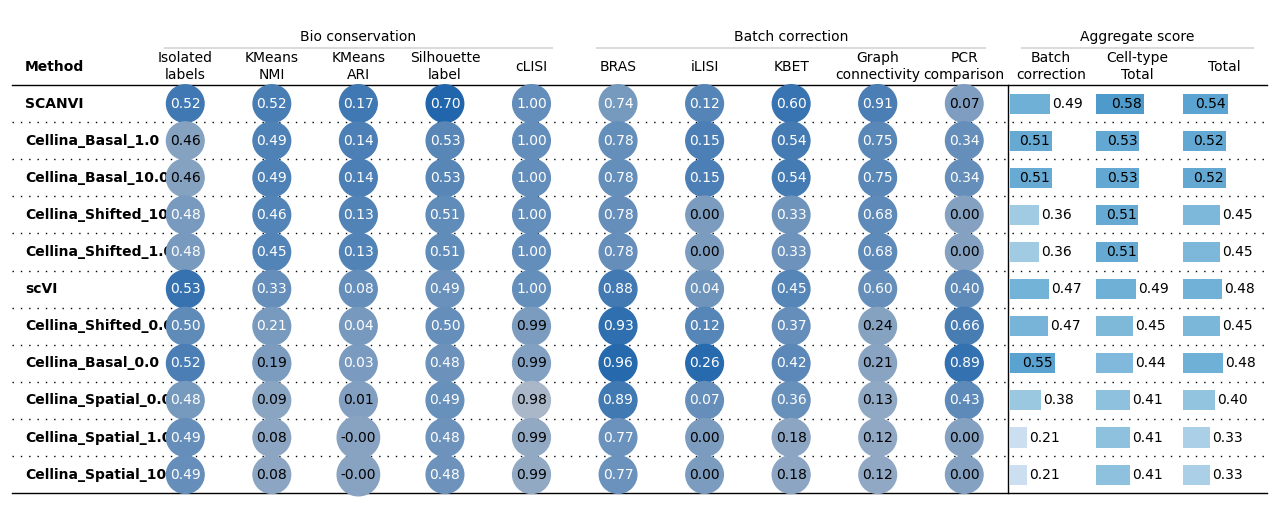

In [36]:
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'

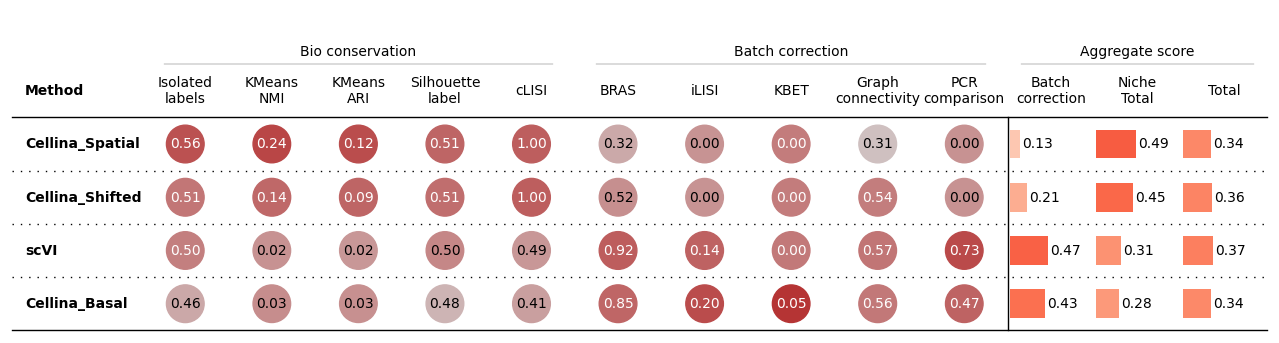

In [15]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


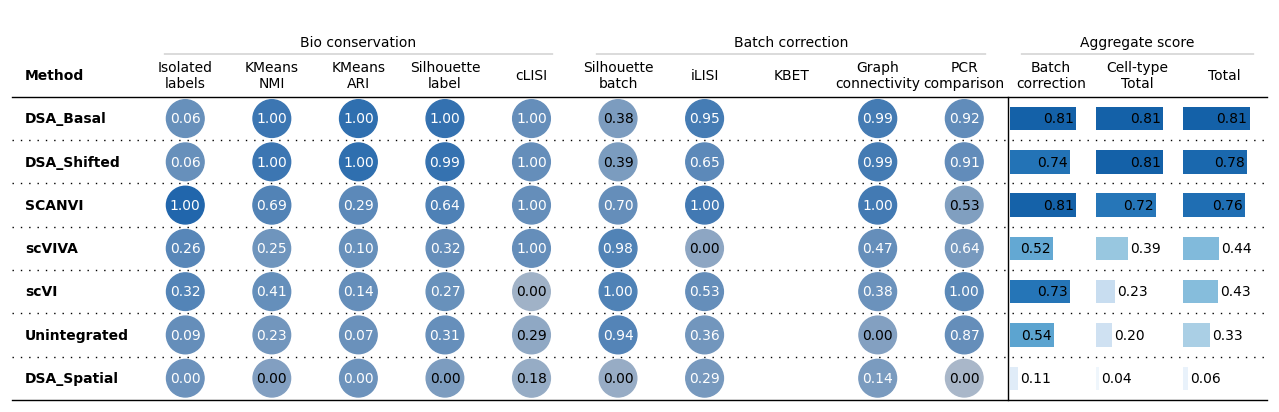

In [13]:

plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'


/data/ddimitrov/software/miniforge3/envs/benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


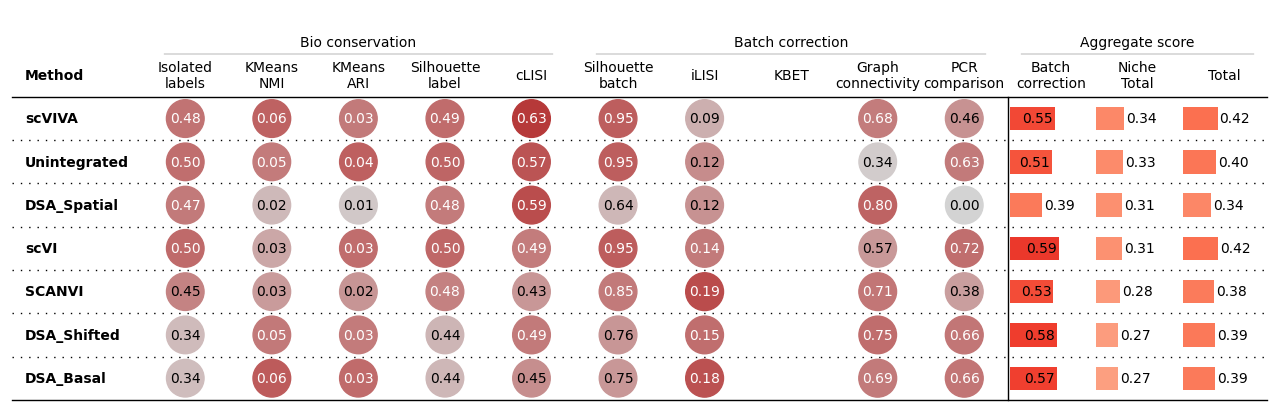

In [14]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

## OOD Classification

In [15]:
import pandas as pd
import scanpy as sc

from dsa.benchmarking.metrics import benchmark_latents_from_anndata

pd.set_option("display.max_columns", None)

In [ ]:
niche_results = benchmark_latents_from_anndata(adata,
                                            label_key=niche_key,
                                            model_keys=OBSM_KEYS,
                                            n_bootstrap=100)
niche_results.to_csv(f"../../results/{dataset_name}_class_niche.csv")

In [ ]:
plot_metric_by_split(
    niche_results,
    metric="f1_macro",
    title="",
    ylabel="F1 Score",
    # palette=gray_to_red,
    figsize=(6,6)
)

In [ ]:
plot_metric_by_split(
    niche_results,
    metric="accuracy",
    title="",
    ylabel="Accuracy",
    # palette=gray_to_red,
    figsize=(6,6)
)

In [ ]:
ct_results = benchmark_latents_from_anndata(adata,
                                            label_key=celltype_key,
                                            model_keys=OBSM_KEYS,
                                            n_bootstrap=100)
ct_results.to_csv(f"../../results/{dataset_name}_class_ct.csv")

In [ ]:
plot_metric_by_split(
    ct_results,
    metric="f1_macro",
    title="",
    ylabel="F1 Score",
    # palette=gray_to_red,
    figsize=(6,6)
)

In [ ]:
plot_metric_by_split(
    ct_results,
    metric="accuracy",
    title="",
    ylabel="Accuracy",
    # palette=gray_to_red,
    figsize=(6,6)
)